<a href="https://colab.research.google.com/github/HitenPatil27/Task-5-Decision-Trees-and-Random-Forests/blob/main/Task_5_Decision_Trees_and_Random_Forests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Import necessary libraries & Load the dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import graphviz
from IPython.display import Image

df = pd.read_csv('/content/heart.csv')

Step 2: Display basic info about the dataset &

In [4]:
print("Dataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0     

Step 3: Separate features and target & Split the data into training and testing sets

In [5]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Step 4: Standardize the features

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Step 5: Train a Decision Tree Classifier and visualize the tree


1. Decision Tree Classifier:
Decision Tree Accuracy: 0.9707792207792207
Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       159
           1       1.00      0.94      0.97       149

    accuracy                           0.97       308
   macro avg       0.97      0.97      0.97       308
weighted avg       0.97      0.97      0.97       308

Decision tree visualization saved as decision_tree.pdf


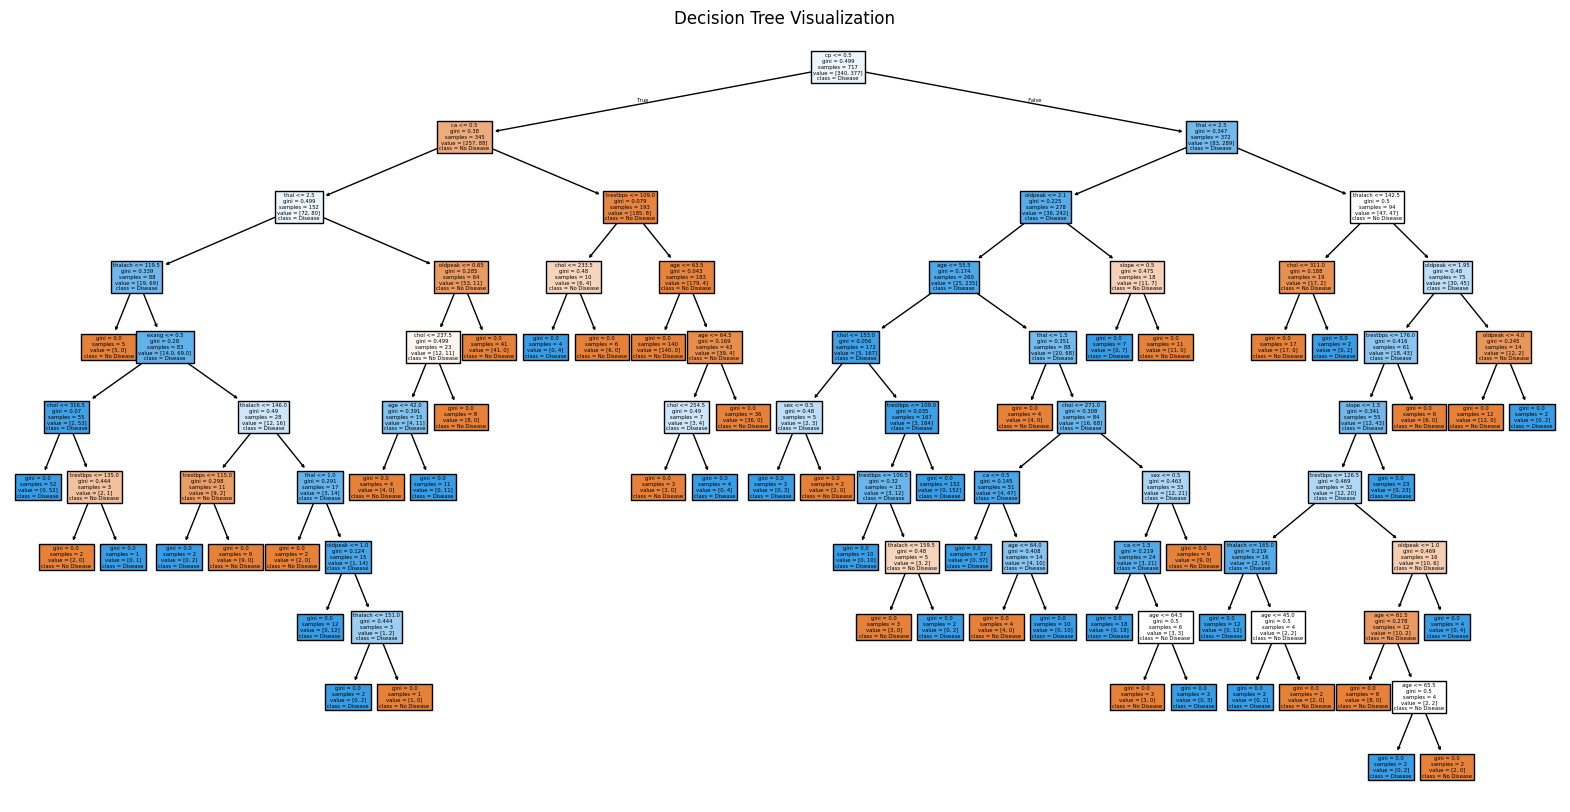

In [7]:
print("\n1. Decision Tree Classifier:")
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt.predict(X_test)

# Evaluate performance
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

# Visualize the decision tree
dot_data = export_graphviz(dt, out_file=None,
                          feature_names=X.columns,
                          class_names=['No Disease', 'Disease'],
                          filled=True, rounded=True,
                          special_characters=True)
graph = graphviz.Source(dot_data)
graph.render("decision_tree")  # This saves to a file
print("Decision tree visualization saved as decision_tree.pdf")

# Display the tree in Colab (alternative)
plt.figure(figsize=(20,10))
from sklearn.tree import plot_tree
plot_tree(dt, feature_names=X.columns, class_names=['No Disease', 'Disease'], filled=True)
plt.title("Decision Tree Visualization")
plt.show()

Step 6: Analyze overfitting and control tree depth


2. Analyzing Overfitting and Controlling Tree Depth:


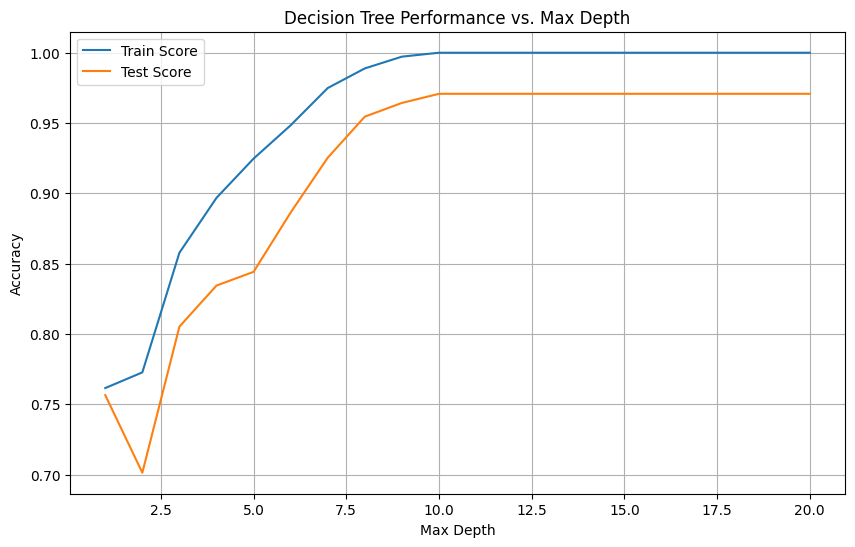

Best max depth based on test score: 10
Optimized Decision Tree Accuracy: 0.9707792207792207


In [8]:
print("\n2. Analyzing Overfitting and Controlling Tree Depth:")

# Test different depths
max_depths = range(1, 21)
train_scores = []
test_scores = []

for depth in max_depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(dt.score(X_train, y_train))
    test_scores.append(dt.score(X_test, y_test))

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(max_depths, train_scores, label='Train Score')
plt.plot(max_depths, test_scores, label='Test Score')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Performance vs. Max Depth')
plt.legend()
plt.grid()
plt.show()

# Find the best depth
best_depth = max_depths[np.argmax(test_scores)]
print(f"Best max depth based on test score: {best_depth}")

# Train with best depth
dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_best.fit(X_train, y_train)
y_pred_dt_best = dt_best.predict(X_test)
print("Optimized Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt_best))

Step 7: Train a Random Forest and compare accuracy

In [9]:
print("\n3. Random Forest Classifier:")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf.predict(X_test)

# Evaluate performance
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Compare with decision tree
print("\nComparison:")
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt_best):.4f}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")


3. Random Forest Classifier:
Random Forest Accuracy: 0.9805194805194806
Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       159
           1       1.00      0.96      0.98       149

    accuracy                           0.98       308
   macro avg       0.98      0.98      0.98       308
weighted avg       0.98      0.98      0.98       308


Comparison:
Decision Tree Accuracy: 0.9708
Random Forest Accuracy: 0.9805


Step 8: Interpret feature importances


4. Feature Importances:
     Feature  Importance
2         cp    0.132274
7    thalach    0.125039
11        ca    0.122912
9    oldpeak    0.122852
12      thal    0.113005
0        age    0.085554
4       chol    0.079872
3   trestbps    0.068356
10     slope    0.051335
8      exang    0.042210
1        sex    0.028721
6    restecg    0.018155
5        fbs    0.009714


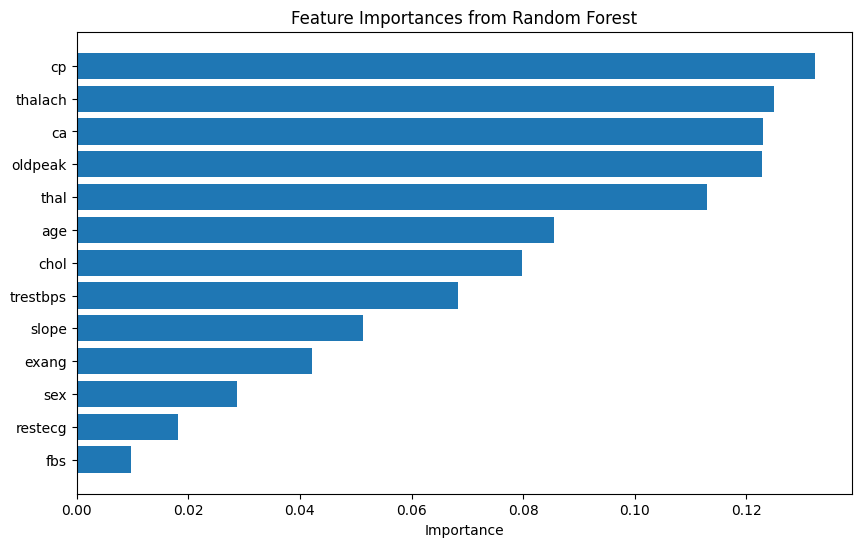

In [10]:
print("\n4. Feature Importances:")
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importances)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Feature'], feature_importances['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importances from Random Forest')
plt.gca().invert_yaxis()
plt.show()

Step 9: Evaluate using cross-validation

In [11]:
print("\n5. Cross-Validation Results:")

# Decision Tree with best depth
dt_scores = cross_val_score(dt_best, X, y, cv=5)
print(f"Decision Tree CV Accuracy: {dt_scores.mean():.4f} (±{dt_scores.std():.4f})")

# Random Forest
rf_scores = cross_val_score(rf, X, y, cv=5)
print(f"Random Forest CV Accuracy: {rf_scores.mean():.4f} (±{rf_scores.std():.4f})")


5. Cross-Validation Results:
Decision Tree CV Accuracy: 1.0000 (±0.0000)
Random Forest CV Accuracy: 0.9971 (±0.0059)
